비지도학습 문제 3

와인 품질 데이터로 클러스터링을 활용한 품질 분류

문제에서 제외 할 것
- 각 클러스터가 특정 와인 품질(quality) 점수와 관련이 있는지 탐색하세요

0.1892040681108649


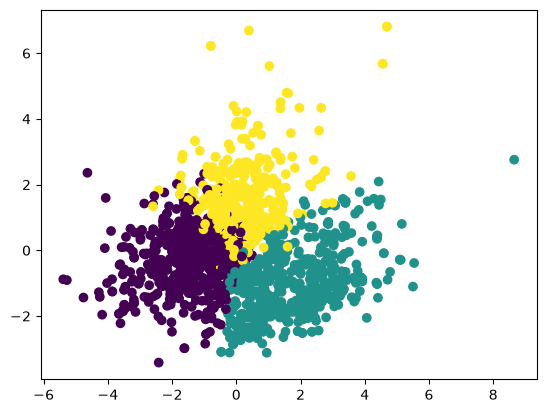

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 데이터 로드
# Red Wine Quality 데이터셋(CSV 파일)을 읽어와 데이터프레임으로 변환합니다.
df = pd.read_csv('winequality-red.csv')

# 2. 피처와 타겟(레이블) 분리
# 비지도학습(군집화)에는 정답인 'quality'가 필요 없으므로, 화학적 특성(X)만 추출합니다.
X = df.drop(columns=['quality'])
y = df['quality']  # 향후 군집 결과와 비교 분석하기 위해 타겟 변수로 따로 저장해둡니다.

# 3. 피처 스케일링 (표준화)
# 와인 데이터의 각 특성(단위, 값의 범위)이 서로 크게 다르므로, 유클리드 거리 기반인 K-Means가 
# 특정 변수(예: 수치가 큰 proline 등)에 지배당하지 않도록 평균 0, 분산 1로 정규화합니다.
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X)

# 4. K-Means 클러스터링 모델 생성 및 학습
# 3개의 군집(K=3)으로 분류하기 위해 모델을 선언합니다.
# random_state는 일관된 결과를 위한 난수 고정값이며, n_init='auto'는 최적의 초기 중심점 설정을 자동화합니다.
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)
# 모델을 학습(fit)시킴과 동시에, 각 데이터 포인트가 속한 군집 번호(0, 1, 2)를 예측하여 할당합니다.
wine_labels = kmeans.fit_predict(X_wine_scaled)

# 5. 실루엣 평가 (Silhouette Score)
# 군집화가 얼마나 뚜렷하게 잘 분류되었는지 평가합니다. (1에 가까울수록 군집이 잘 구분된 것입니다.)
wine_sil_score = silhouette_score(X_wine_scaled, wine_labels)
print(f"평균 실루엣 계수: {wine_sil_score}")

# print(X_wine_scaled.shape) # 주석 해제 시 스케일링된 원본 데이터의 형태(행, 열)를 확인 가능

# 6. PCA를 이용한 차원 축소
# 시각화를 위해 여러 개의 고차원(화학적 특성들) 데이터를 2차원(주성분 2개) 공간으로 축소합니다.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)
# print(X_pca.shape) # 주석 해제 시 2차원(행, 2)으로 축소된 데이터 형태 확인 가능

# 7. 결과 시각화
# 2차원으로 축소된 주성분(PCA Component 1, 2)을 축으로 삼아 산점도를 그립니다.
# c=wine_labels 옵션을 통해 K-Means로 예측된 3개의 군집별로 색상을 다르게 지정하여 구분합니다.
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=wine_labels,
    cmap='viridis' 
)
plt.title('K-Means Clustering of Wine Quality (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

0.1892040681108649


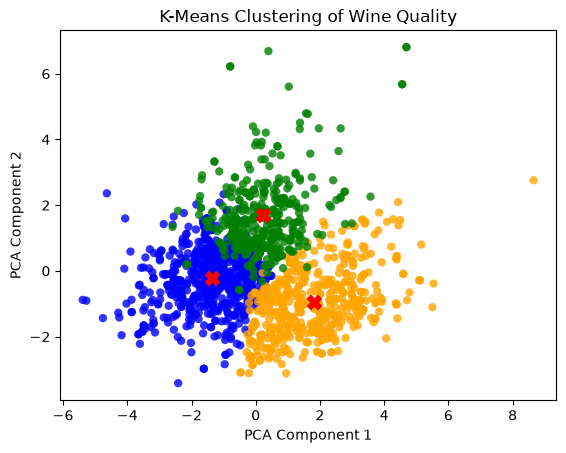

In [26]:
# 추가로 GPT도움을 받아 plt를 꾸몄습니다.
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-red.csv')

X = df.drop(columns=['quality'])
y = df['quality']

scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)
wine_labels = kmeans.fit_predict(X_wine_scaled)
wine_sil_score = silhouette_score(X_wine_scaled,wine_labels)
print(wine_sil_score)
#print(X_wine_scaled.shape)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)
#print(X_pca.shape)
centroids_pca = pca.transform(kmeans.cluster_centers_)

colors = ['blue', 'orange', 'green'] 
for cluster_id in range(3):
    plt.scatter(
        X_pca[wine_labels == cluster_id, 0], 
        X_pca[wine_labels == cluster_id, 1], 
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.8,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    marker='X', 
    s=100,       
    c='red', 
    linewidth=1,
    label='Centroids'
)

plt.title('K-Means Clustering of Wine Quality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()
